# Projeto de Banco de Dados — Sistema de Gestão para Associação de Moradores

**Disciplina:** Banco de Dados (CEAPI) · **Curso:** Ciência de Dados e Inteligência Artificial — PUC-SP
**SGBD:** SQLite 3 · **Integrantes:** _______________________________________________

Este notebook é autoexecutável: ao rodar todas as células (*Run All*), ele cria o arquivo
`associacao_moradores.db`, popula os dados de teste e executa as consultas exibindo os resultados.

## 1. Diagnóstico Inicial

### Contexto
A Associação de Moradores do Condomínio Residencial Vila Verde reúne dois blocos de unidades — o **Bloco A**, de apartamentos, e o **Bloco B**, de casas — totalizando dezenas de famílias. A associação administra a cobrança das taxas mensais de condomínio, registra e acompanha ocorrências (reclamações, manutenções e problemas estruturais), organiza assembleias e reuniões e controla a reserva das áreas comuns (salão, churrasqueira, quadra).

Hoje esse controle é feito de forma **manual e dispersa**: planilhas isoladas, cadernos, grupos de mensagens e papéis, cada um sob responsabilidade de uma pessoa diferente, sem integração.

### Problemas enfrentados sem o sistema
- **Inadimplência sem visibilidade:** não há forma rápida de saber quem está em atraso, em qual mês e quanto deve.
- **Histórico fragmentado:** ao trocar de unidade ou de inquilino, o histórico de ocupação se perde.
- **Ocorrências esquecidas:** reclamações informais ficam sem status nem responsável.
- **Conflitos de reserva:** marcação de áreas comuns por mensagem gera dupla reserva.
- **Decisões pouco transparentes:** pautas e atas dispersas dificultam comprovar o que foi decidido e quem participou.

### Benefícios da solução proposta
Um banco de dados relacional centraliza tudo em uma base íntegra e consultável:
- Centralização de moradores, unidades, contribuições, ocorrências, reuniões e reservas.
- Identificação imediata de inadimplentes e cálculo automático da arrecadação por mês.
- Registro histórico completo dos vínculos morador–unidade.
- Rastreabilidade de ocorrências (status/responsável) e controle de reservas sem conflito.
- Relatórios gerenciais via SQL, dando transparência à administração.

## 2. Modelagem — Diagrama Entidade-Relacionamento

O modelo tem **8 tabelas**: as 7 do escopo mais a associativa `Reuniao_Participante`, necessária para o N:M entre Reunião e Morador (presença).

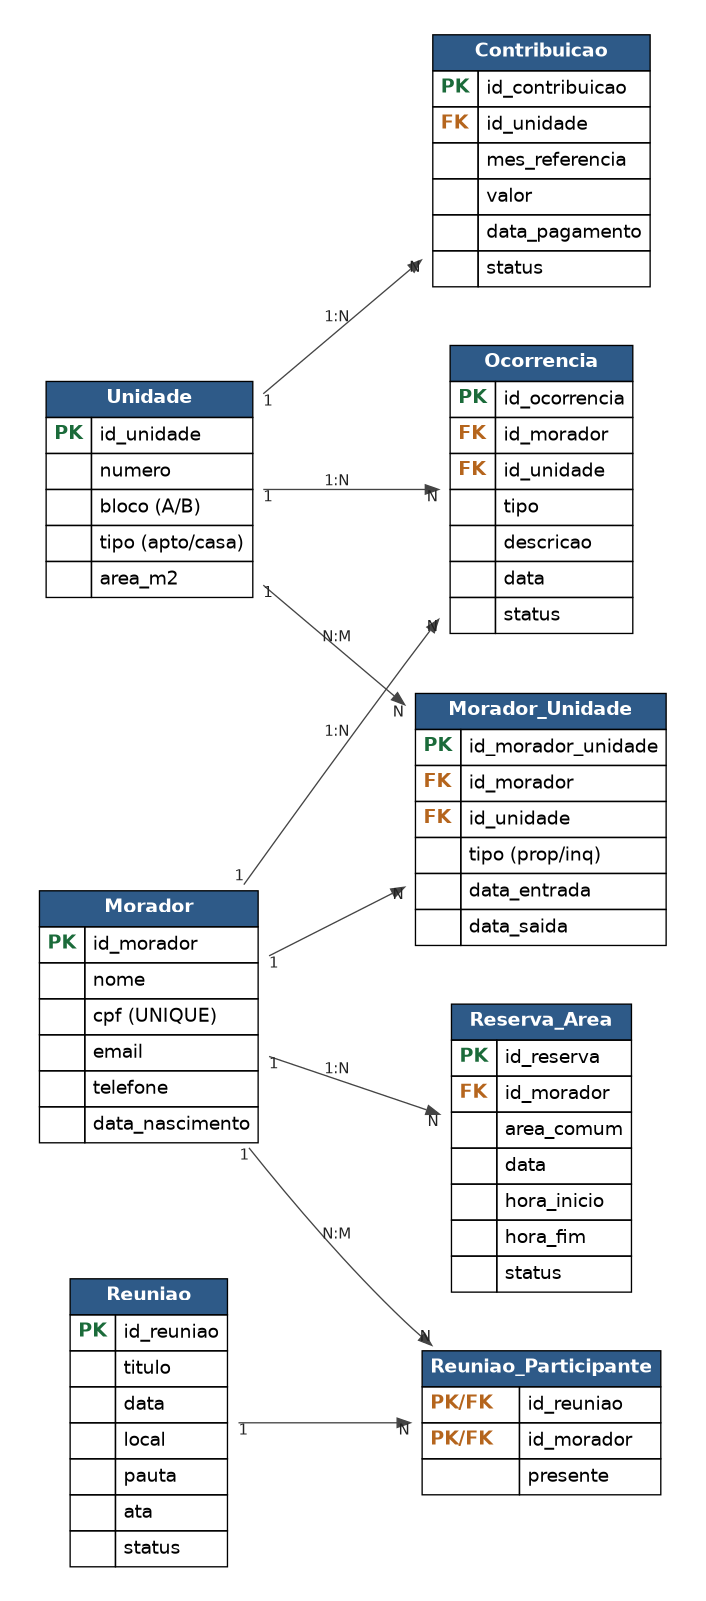

**Relacionamentos e cardinalidades**
- `Morador` **(N:M)** `Unidade` — resolvido por `Morador_Unidade` (um morador pode ocupar várias unidades no tempo; uma unidade pode ter vários moradores).
- `Unidade` **(1:N)** `Contribuicao` — uma cobrança por unidade por mês.
- `Morador` **(1:N)** `Ocorrencia` e `Unidade` **(1:N)** `Ocorrencia`.
- `Morador` **(1:N)** `Reserva_Area`.
- `Reuniao` **(N:M)** `Morador` — resolvido por `Reuniao_Participante`.

> **Sobre o 1:1:** não há relacionamento 1:1 natural neste domínio (tudo é 1:N ou N:M). Um 1:1 surgiria, por exemplo, se cada unidade tivesse exatamente um medidor de água individual (`Unidade` 1:1 `Medidor`), entidade fora deste escopo.

## 3. Implementação no SGBD (SQLite)

### 3.1 Conexão
Criamos o arquivo `associacao_moradores.db` e ligamos a checagem de chaves estrangeiras (no SQLite ela vem desligada por padrão).

In [1]:
import sqlite3, os
import pandas as pd

DB = "associacao_moradores.db"
if os.path.exists(DB):
    os.remove(DB)          # recria do zero a cada execução

con = sqlite3.connect(DB)
con.execute("PRAGMA foreign_keys = ON;")

def q(sql):
    """Executa um SELECT e devolve o resultado como DataFrame."""
    return pd.read_sql_query(sql, con)

print("Conectado a", DB)

Conectado a associacao_moradores.db


### 3.2 Criação das tabelas (DDL)
Principais decisões: chaves substitutas (`id` auto-incremento), integridade referencial via `FOREIGN KEY`, e restrições `CHECK`/`UNIQUE` para garantir domínios e regras de negócio.

In [2]:
ddl = """
PRAGMA foreign_keys = ON;

-- Limpeza opcional para reexecução do script sem erro de "table already exists".
DROP TABLE IF EXISTS Reuniao_Participante;
DROP TABLE IF EXISTS Reserva_Area;
DROP TABLE IF EXISTS Reuniao;
DROP TABLE IF EXISTS Ocorrencia;
DROP TABLE IF EXISTS Contribuicao;
DROP TABLE IF EXISTS Morador_Unidade;
DROP TABLE IF EXISTS Morador;
DROP TABLE IF EXISTS Unidade;


-- ============================================================================
--  SEÇÃO 3 — CRIAÇÃO DAS TABELAS (DDL)
-- ============================================================================

-- ----------------------------------------------------------------------------
--  Unidade: cada apartamento/casa do condomínio. É a unidade física cobrada.
-- ----------------------------------------------------------------------------
CREATE TABLE Unidade (
    id_unidade INTEGER PRIMARY KEY AUTOINCREMENT,
    numero     INTEGER NOT NULL,
    bloco      TEXT    NOT NULL CHECK (bloco IN ('A','B')),
    tipo       TEXT    NOT NULL CHECK (tipo IN ('apartamento','casa')),
    area_m2    REAL    NOT NULL CHECK (area_m2 > 0),
    -- Não pode existir o mesmo número repetido dentro de um mesmo bloco.
    UNIQUE (numero, bloco)
);

-- ----------------------------------------------------------------------------
--  Morador: pessoa física. CPF é único (identifica a pessoa, não a unidade).
-- ----------------------------------------------------------------------------
CREATE TABLE Morador (
    id_morador      INTEGER PRIMARY KEY AUTOINCREMENT,
    nome            TEXT NOT NULL,
    -- CPF guardado só com dígitos (11 caracteres); UNIQUE evita cadastro duplicado.
    cpf             TEXT NOT NULL UNIQUE CHECK (length(cpf) = 11),
    email           TEXT,
    telefone        TEXT,
    data_nascimento TEXT   -- formato ISO 'AAAA-MM-DD'
);

-- ----------------------------------------------------------------------------
--  Morador_Unidade: tabela ASSOCIATIVA que resolve o N:M entre Morador e
--  Unidade. Um morador pode ocupar várias unidades ao longo do tempo e uma
--  unidade pode ter vários moradores (casal, troca de inquilino etc.).
--  data_saida NULL = vínculo ainda ativo.
-- ----------------------------------------------------------------------------
CREATE TABLE Morador_Unidade (
    id_morador_unidade INTEGER PRIMARY KEY AUTOINCREMENT,
    id_morador   INTEGER NOT NULL,
    id_unidade   INTEGER NOT NULL,
    tipo         TEXT    NOT NULL CHECK (tipo IN ('proprietario','inquilino')),
    data_entrada TEXT    NOT NULL,
    data_saida   TEXT,   -- NULL enquanto o morador ainda mora na unidade
    FOREIGN KEY (id_morador) REFERENCES Morador(id_morador),
    FOREIGN KEY (id_unidade) REFERENCES Unidade(id_unidade),
    -- Saída nunca pode ser anterior à entrada.
    CHECK (data_saida IS NULL OR data_saida >= data_entrada)
);

-- ----------------------------------------------------------------------------
--  Contribuicao: cobrança mensal (taxa de condomínio) por UNIDADE.
--  Relação 1:N -> uma unidade tem muitas contribuições (uma por mês).
-- ----------------------------------------------------------------------------
CREATE TABLE Contribuicao (
    id_contribuicao INTEGER PRIMARY KEY AUTOINCREMENT,
    id_unidade      INTEGER NOT NULL,
    mes_referencia  TEXT    NOT NULL,                 -- 'AAAA-MM'
    valor           REAL    NOT NULL CHECK (valor > 0),
    data_pagamento  TEXT,                             -- NULL enquanto não pago
    status          TEXT    NOT NULL CHECK (status IN ('pago','pendente','atrasado')),
    FOREIGN KEY (id_unidade) REFERENCES Unidade(id_unidade),
    -- Uma única cobrança por unidade em cada mês de referência.
    UNIQUE (id_unidade, mes_referencia),
    -- Regra de integridade: se está 'pago', precisa ter data de pagamento;
    -- se não está pago, não pode ter data de pagamento.
    CHECK (
        (status = 'pago'  AND data_pagamento IS NOT NULL) OR
        (status <> 'pago' AND data_pagamento IS NULL)
    )
);

-- ----------------------------------------------------------------------------
--  Ocorrencia: chamado/reclamação aberta por um morador, vinculada à unidade.
--  Relação 1:N a partir de Morador e a partir de Unidade.
-- ----------------------------------------------------------------------------
CREATE TABLE Ocorrencia (
    id_ocorrencia INTEGER PRIMARY KEY AUTOINCREMENT,
    id_morador    INTEGER NOT NULL,
    id_unidade    INTEGER NOT NULL,
    tipo          TEXT    NOT NULL,   -- ex.: 'Barulho', 'Vazamento', 'Manutenção'
    descricao     TEXT,
    data          TEXT    NOT NULL,
    status        TEXT    NOT NULL CHECK (status IN ('aberta','em andamento','resolvida')),
    FOREIGN KEY (id_morador) REFERENCES Morador(id_morador),
    FOREIGN KEY (id_unidade) REFERENCES Unidade(id_unidade)
);

-- ----------------------------------------------------------------------------
--  Reuniao: assembleias e reuniões da associação.
-- ----------------------------------------------------------------------------
CREATE TABLE Reuniao (
    id_reuniao INTEGER PRIMARY KEY AUTOINCREMENT,
    titulo     TEXT NOT NULL,
    data       TEXT NOT NULL,
    local      TEXT,
    pauta      TEXT,
    ata        TEXT,   -- preenchida depois da reunião realizada
    status     TEXT NOT NULL CHECK (status IN ('agendada','realizada','cancelada'))
);

-- ----------------------------------------------------------------------------
--  Reserva_Area: reserva de área comum por um morador.
--  Relação 1:N -> um morador faz muitas reservas.
-- ----------------------------------------------------------------------------
CREATE TABLE Reserva_Area (
    id_reserva  INTEGER PRIMARY KEY AUTOINCREMENT,
    area_comum  TEXT    NOT NULL CHECK (area_comum IN ('salao','churrasqueira','quadra','piscina','playground')),
    id_morador  INTEGER NOT NULL,
    data        TEXT    NOT NULL,
    hora_inicio TEXT    NOT NULL,   -- 'HH:MM'
    hora_fim    TEXT    NOT NULL,   -- 'HH:MM'
    status      TEXT    NOT NULL CHECK (status IN ('confirmada','pendente','cancelada')),
    FOREIGN KEY (id_morador) REFERENCES Morador(id_morador),
    -- Horário de término precisa ser depois do início.
    CHECK (hora_fim > hora_inicio)
);

-- ----------------------------------------------------------------------------
--  Reuniao_Participante: tabela ASSOCIATIVA (N:M) entre Reuniao e Morador.
--  Necessária para registrar "reuniões com participantes" / presença.
--  PK composta evita o mesmo morador duas vezes na mesma reunião.
-- ----------------------------------------------------------------------------
CREATE TABLE Reuniao_Participante (
    id_reuniao INTEGER NOT NULL,
    id_morador INTEGER NOT NULL,
    presente   INTEGER NOT NULL DEFAULT 1 CHECK (presente IN (0,1)),  -- 0=ausente, 1=presente
    PRIMARY KEY (id_reuniao, id_morador),
    FOREIGN KEY (id_reuniao) REFERENCES Reuniao(id_reuniao),
    FOREIGN KEY (id_morador) REFERENCES Morador(id_morador)
);


-- ============================================================================
"""
con.executescript(ddl)
con.commit()
print("Tabelas criadas com sucesso.")

Tabelas criadas com sucesso.


## 4. Inserção de Dados de Teste
Dados fictícios e realistas: 12 moradores, 8 unidades (4 no Bloco A e 4 no Bloco B), 24 contribuições (8 unidades × 3 meses) com status variados, 6 ocorrências, 2 reuniões com participantes e 3 reservas.

In [3]:
dml = """
INSERT INTO Unidade (numero, bloco, tipo, area_m2) VALUES
    (101, 'A', 'apartamento', 65.5),   -- id 1
    (102, 'A', 'apartamento', 65.5),   -- id 2
    (201, 'A', 'apartamento', 72.0),   -- id 3
    (202, 'A', 'apartamento', 72.0),   -- id 4
    (1,   'B', 'casa',        120.0),  -- id 5
    (2,   'B', 'casa',        120.0),  -- id 6
    (3,   'B', 'casa',        95.0),   -- id 7
    (4,   'B', 'casa',        95.0);   -- id 8

-- ---- Moradores (12 moradores) ---------------------------------------------
INSERT INTO Morador (nome, cpf, email, telefone, data_nascimento) VALUES
    ('Ana Carolina Souza',     '12345678901', 'ana.souza@email.com',      '(11) 98123-4501', '1985-04-12'), -- 1
    ('Bruno Henrique Lima',    '23456789012', 'bruno.lima@email.com',     '(11) 98123-4502', '1990-09-23'), -- 2
    ('Carla Mendes Oliveira',  '34567890123', 'carla.mendes@email.com',   '(11) 98123-4503', '1978-12-01'), -- 3
    ('Diego Ferreira Santos',  '45678901234', 'diego.santos@email.com',   '(11) 98123-4504', '1995-06-15'), -- 4
    ('Eduarda Ribeiro Alves',  '56789012345', 'eduarda.alves@email.com',  '(11) 98123-4505', '1982-02-28'), -- 5
    ('Felipe Augusto Costa',   '67890123456', 'felipe.costa@email.com',   '(11) 98123-4506', '1998-11-07'), -- 6
    ('Gabriela Martins Rocha', '78901234567', 'gabriela.rocha@email.com', '(11) 98123-4507', '1988-07-19'), -- 7
    ('Henrique Barbosa Dias',  '89012345678', 'henrique.dias@email.com',  '(11) 98123-4508', '1975-03-30'), -- 8
    ('Isabela Cardoso Pinto',  '90123456789', 'isabela.pinto@email.com',  '(11) 98123-4509', '1993-10-05'), -- 9
    ('Joao Pedro Almeida',     '01234567890', 'joao.almeida@email.com',   '(11) 98123-4510', '1991-01-22'), -- 10
    ('Larissa Gomes Teixeira', '11223344556', 'larissa.gomes@email.com',  '(11) 98123-4511', '1987-08-14'), -- 11
    ('Marcos Vinicius Nunes',  '22334455667', 'marcos.nunes@email.com',   '(11) 98123-4512', '1996-05-03'); -- 12

-- ---- Vínculos Morador x Unidade -------------------------------------------
-- Casos demonstram o N:M: unidades com 2 moradores (casal), e um morador
-- (Marcos, id 12) que TROCOU de unidade no tempo (vínculo encerrado + novo).
INSERT INTO Morador_Unidade (id_morador, id_unidade, tipo, data_entrada, data_saida) VALUES
    (1,  1, 'proprietario', '2018-03-15', NULL),
    (2,  2, 'proprietario', '2019-07-01', NULL),
    (11, 2, 'proprietario', '2019-07-01', NULL),                 -- cônjuge co-proprietário da unidade 2
    (3,  3, 'inquilino',    '2021-02-10', NULL),
    (4,  4, 'proprietario', '2017-11-20', NULL),
    (5,  5, 'proprietario', '2015-05-05', NULL),
    (9,  5, 'proprietario', '2015-05-05', NULL),                 -- co-proprietária da unidade 5
    (6,  6, 'inquilino',    '2022-01-15', NULL),
    (10, 6, 'inquilino',    '2022-01-15', NULL),                 -- casal alugando a unidade 6
    (7,  7, 'proprietario', '2020-09-30', NULL),
    (8,  8, 'proprietario', '2016-08-12', NULL),
    (12, 8, 'inquilino',    '2021-06-01', '2023-12-20'),         -- vínculo ANTIGO (já saiu)
    (12, 7, 'inquilino',    '2024-01-10', NULL);                 -- vínculo ATUAL do mesmo morador

-- ---- Contribuições: 3 meses de referência (jan, fev, mar/2025) -------------
-- Valor: apartamentos (unid. 1-4) = R$ 450,00 ; casas (unid. 5-8) = R$ 650,00.
-- Status variados para validar consultas de inadimplência e arrecadação.

-- Janeiro/2025 (quase tudo pago)
INSERT INTO Contribuicao (id_unidade, mes_referencia, valor, data_pagamento, status) VALUES
    (1, '2025-01', 450.0, '2025-01-08', 'pago'),
    (2, '2025-01', 450.0, '2025-01-05', 'pago'),
    (3, '2025-01', 450.0, '2025-01-10', 'pago'),
    (4, '2025-01', 450.0, NULL,         'atrasado'),   -- unidade 4 inadimplente desde jan
    (5, '2025-01', 650.0, '2025-01-07', 'pago'),
    (6, '2025-01', 650.0, '2025-01-09', 'pago'),
    (7, '2025-01', 650.0, '2025-01-06', 'pago'),
    (8, '2025-01', 650.0, '2025-01-12', 'pago');

-- Fevereiro/2025 (mistura maior)
INSERT INTO Contribuicao (id_unidade, mes_referencia, valor, data_pagamento, status) VALUES
    (1, '2025-02', 450.0, '2025-02-08', 'pago'),
    (2, '2025-02', 450.0, '2025-02-06', 'pago'),
    (3, '2025-02', 450.0, NULL,         'pendente'),
    (4, '2025-02', 450.0, NULL,         'atrasado'),
    (5, '2025-02', 650.0, '2025-02-09', 'pago'),
    (6, '2025-02', 650.0, NULL,         'atrasado'),
    (7, '2025-02', 650.0, '2025-02-05', 'pago'),
    (8, '2025-02', 650.0, '2025-02-11', 'pago');

-- Março/2025 (vários em aberto)
INSERT INTO Contribuicao (id_unidade, mes_referencia, valor, data_pagamento, status) VALUES
    (1, '2025-03', 450.0, '2025-03-07', 'pago'),
    (2, '2025-03', 450.0, NULL,         'pendente'),
    (3, '2025-03', 450.0, NULL,         'pendente'),
    (4, '2025-03', 450.0, NULL,         'atrasado'),
    (5, '2025-03', 650.0, '2025-03-08', 'pago'),
    (6, '2025-03', 650.0, NULL,         'atrasado'),
    (7, '2025-03', 650.0, NULL,         'pendente'),
    (8, '2025-03', 650.0, '2025-03-10', 'pago');

-- ---- Ocorrências (6 tipos diferentes) -------------------------------------
INSERT INTO Ocorrencia (id_morador, id_unidade, tipo, descricao, data, status) VALUES
    (3, 3, 'Barulho',             'Som alto vindo da unidade vizinha apos as 23h.',          '2025-03-02', 'aberta'),
    (5, 5, 'Vazamento',           'Infiltracao no teto da garagem proxima a casa 1.',        '2025-03-05', 'em andamento'),
    (1, 1, 'Manutencao Elevador', 'Elevador do bloco A travando entre andares.',             '2025-02-18', 'resolvida'),
    (7, 7, 'Animal Solto',        'Cachorro sem coleira circulando na area comum.',          '2025-03-11', 'aberta'),
    (2, 2, 'Vaga de Garagem',     'Carro estacionado em vaga de outro morador.',             '2025-01-25', 'resolvida'),
    (8, 8, 'Iluminacao',          'Lampada queimada no corredor externo do bloco B.',        '2025-03-14', 'em andamento');

-- ---- Reuniões (2) ----------------------------------------------------------
INSERT INTO Reuniao (titulo, data, local, pauta, ata, status) VALUES
    ('Assembleia Geral Ordinaria 2025',
     '2025-03-20', 'Salao de Festas',
     'Prestacao de contas 2024; aprovacao do orcamento 2025; eleicao do sindico.',
     'Aprovadas as contas de 2024 por maioria. Orcamento 2025 aprovado com reajuste de 5% na taxa. Sindico reeleito.',
     'realizada'),
    ('Reuniao Extraordinaria - Reforma da Fachada',
     '2025-04-15', 'Salao de Festas',
     'Apresentacao de orcamentos para pintura da fachada e definicao de rateio.',
     NULL,
     'agendada');

-- ---- Participantes das reuniões (N:M) -------------------------------------
-- Reunião 1 (Assembleia, realizada): vários moradores, alguns ausentes.
INSERT INTO Reuniao_Participante (id_reuniao, id_morador, presente) VALUES
    (1, 1, 1),
    (1, 2, 1),
    (1, 4, 0),   -- convocado, mas ausente
    (1, 5, 1),
    (1, 7, 1),
    (1, 8, 1),
    (1, 11, 0);  -- ausente
-- Reunião 2 (Extraordinária, agendada): confirmados como participantes.
INSERT INTO Reuniao_Participante (id_reuniao, id_morador, presente) VALUES
    (2, 1, 1),
    (2, 3, 1),
    (2, 5, 1),
    (2, 6, 1);

-- ---- Reservas de áreas comuns (3) -----------------------------------------
INSERT INTO Reserva_Area (area_comum, id_morador, data, hora_inicio, hora_fim, status) VALUES
    ('salao',         1, '2025-05-10', '14:00', '22:00', 'confirmada'),
    ('churrasqueira', 5, '2025-05-17', '11:00', '16:00', 'confirmada'),
    ('quadra',        7, '2025-05-20', '18:00', '20:00', 'pendente');


-- ============================================================================
"""
con.executescript(dml)
con.commit()
print("Dados inseridos com sucesso.")

Dados inseridos com sucesso.


### 4.1 Validação da carga (integridade e contagens)

In [4]:
# Verifica se nenhuma chave estrangeira ficou órfã (lista vazia = tudo certo)
print("foreign_key_check:", con.execute("PRAGMA foreign_key_check;").fetchall())

tabelas = ["Unidade","Morador","Morador_Unidade","Contribuicao",
           "Ocorrencia","Reuniao","Reserva_Area","Reuniao_Participante"]
pd.DataFrame(
    [(t, con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]) for t in tabelas],
    columns=["Tabela","Registros"]
)

foreign_key_check: []


,Tabela,Registros
0,Unidade,8
1,Morador,12
2,Morador_Unidade,13
3,Contribuicao,24
4,Ocorrencia,6
5,Reuniao,2
6,Reserva_Area,3
7,Reuniao_Participante,11


## 5. Consultas de Exemplo

### 5.1 Moradores inadimplentes
Moradores ativos cuja unidade tem contribuições pendentes/atrasadas, com a quantidade de débitos e o total devido.

In [5]:
q("""
SELECT m.nome, u.bloco, u.numero,
       COUNT(*) AS qtd_em_aberto, SUM(c.valor) AS total_devido
FROM Contribuicao c
JOIN Unidade u  ON u.id_unidade = c.id_unidade
JOIN Morador_Unidade mu ON mu.id_unidade = u.id_unidade AND mu.data_saida IS NULL
JOIN Morador m  ON m.id_morador = mu.id_morador
WHERE c.status IN ('pendente','atrasado')
GROUP BY m.id_morador, u.bloco, u.numero
ORDER BY total_devido DESC;
""")

,nome,bloco,numero,qtd_em_aberto,total_devido
0,Diego Ferreira Santos,A,202,3,1350.0
1,Felipe Augusto Costa,B,2,2,1300.0
2,Joao Pedro Almeida,B,2,2,1300.0
3,Carla Mendes Oliveira,A,201,2,900.0
4,Gabriela Martins Rocha,B,3,1,650.0
5,Marcos Vinicius Nunes,B,3,1,650.0
6,Bruno Henrique Lima,A,102,1,450.0
7,Larissa Gomes Teixeira,A,102,1,450.0


### 5.2 Ocorrências abertas por bloco
Ocorrências não resolvidas (abertas + em andamento) agrupadas por bloco.

In [6]:
q("""
SELECT u.bloco, COUNT(*) AS ocorrencias_em_aberto
FROM Ocorrencia o
JOIN Unidade u ON u.id_unidade = o.id_unidade
WHERE o.status IN ('aberta','em andamento')
GROUP BY u.bloco
ORDER BY ocorrencias_em_aberto DESC;
""")

,bloco,ocorrencias_em_aberto
0,B,3
1,A,1


### 5.3 Histórico de reservas por morador
Todas as reservas de áreas comuns feitas por cada morador.

In [7]:
q("""
SELECT m.nome, r.area_comum, r.data, r.hora_inicio, r.hora_fim, r.status
FROM Reserva_Area r
JOIN Morador m ON m.id_morador = r.id_morador
ORDER BY m.nome, r.data;
""")

,nome,area_comum,data,hora_inicio,hora_fim,status
0,Ana Carolina Souza,salao,2025-05-10,14:00,22:00,confirmada
1,Eduarda Ribeiro Alves,churrasqueira,2025-05-17,11:00,16:00,confirmada
2,Gabriela Martins Rocha,quadra,2025-05-20,18:00,20:00,pendente


### 5.4 Total arrecadado por mês
Soma apenas o que foi efetivamente pago em cada mês de referência.

In [8]:
q("""
SELECT c.mes_referencia, COUNT(*) AS qtd_pagamentos, SUM(c.valor) AS total_arrecadado
FROM Contribuicao c
WHERE c.status = 'pago'
GROUP BY c.mes_referencia
ORDER BY c.mes_referencia;
""")

,mes_referencia,qtd_pagamentos,total_arrecadado
0,2025-01,7,3950.0
1,2025-02,5,2850.0
2,2025-03,3,1750.0


### 5.5 Atas das reuniões realizadas
Título, data, local e ata das reuniões já realizadas.

In [9]:
q("""
SELECT titulo, data, local, ata
FROM Reuniao
WHERE status = 'realizada' AND ata IS NOT NULL
ORDER BY data DESC;
""")

,titulo,data,local,ata
0,Assembleia Geral Ordinaria 2025,2025-03-20,Salao de Festas,Aprovadas as contas de 2024 por maioria. Orcam...


### 5.6 Lista de presença por reunião (extra)
Uso da tabela associativa Reuniao_Participante (N:M), com presença/ausência.

In [10]:
q("""
SELECT re.titulo, re.data, m.nome,
       CASE WHEN rp.presente = 1 THEN 'Presente' ELSE 'Ausente' END AS presenca
FROM Reuniao_Participante rp
JOIN Reuniao re ON re.id_reuniao = rp.id_reuniao
JOIN Morador m  ON m.id_morador  = rp.id_morador
ORDER BY re.data, m.nome;
""")

,titulo,data,nome,presenca
0,Assembleia Geral Ordinaria 2025,2025-03-20,Ana Carolina Souza,Presente
1,Assembleia Geral Ordinaria 2025,2025-03-20,Bruno Henrique Lima,Presente
2,Assembleia Geral Ordinaria 2025,2025-03-20,Diego Ferreira Santos,Ausente
3,Assembleia Geral Ordinaria 2025,2025-03-20,Eduarda Ribeiro Alves,Presente
4,Assembleia Geral Ordinaria 2025,2025-03-20,Gabriela Martins Rocha,Presente
5,Assembleia Geral Ordinaria 2025,2025-03-20,Henrique Barbosa Dias,Presente
6,Assembleia Geral Ordinaria 2025,2025-03-20,Larissa Gomes Teixeira,Ausente
7,Reuniao Extraordinaria - Reforma da Fachada,2025-04-15,Ana Carolina Souza,Presente
8,Reuniao Extraordinaria - Reforma da Fachada,2025-04-15,Carla Mendes Oliveira,Presente
9,Reuniao Extraordinaria - Reforma da Fachada,2025-04-15,Eduarda Ribeiro Alves,Presente


### 5.7 Moradores ativos por unidade (extra)
Quem ocupa atualmente cada unidade (vínculo sem data de saída).

In [11]:
q("""
SELECT u.bloco, u.numero, u.tipo, m.nome, mu.tipo AS vinculo
FROM Morador_Unidade mu
JOIN Unidade u ON u.id_unidade = mu.id_unidade
JOIN Morador m ON m.id_morador = mu.id_morador
WHERE mu.data_saida IS NULL
ORDER BY u.bloco, u.numero;
""")

,bloco,numero,tipo,nome,vinculo
0,A,101,apartamento,Ana Carolina Souza,proprietario
1,A,102,apartamento,Bruno Henrique Lima,proprietario
2,A,102,apartamento,Larissa Gomes Teixeira,proprietario
3,A,201,apartamento,Carla Mendes Oliveira,inquilino
4,A,202,apartamento,Diego Ferreira Santos,proprietario
5,B,1,casa,Eduarda Ribeiro Alves,proprietario
6,B,1,casa,Isabela Cardoso Pinto,proprietario
7,B,2,casa,Felipe Augusto Costa,inquilino
8,B,2,casa,Joao Pedro Almeida,inquilino
9,B,3,casa,Gabriela Martins Rocha,proprietario


## 6. Documentação das Entidades

### Unidade
Cada unidade física (apartamento ou casa); é a unidade economicamente cobrada.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_unidade | INTEGER (PK) | Identificador único (auto-incremento). |
| numero | INTEGER, NOT NULL | Número da unidade dentro do bloco. |
| bloco | TEXT, CHECK | Bloco; restrito a 'A' ou 'B'. |
| tipo | TEXT, CHECK | 'apartamento' ou 'casa'. |
| area_m2 | REAL, CHECK > 0 | Área útil em m². |

### Morador
Pessoa física cadastrada; o CPF a identifica unicamente.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_morador | INTEGER (PK) | Identificador único do morador. |
| nome | TEXT, NOT NULL | Nome completo. |
| cpf | TEXT, UNIQUE | CPF (11 dígitos); não repete. |
| email | TEXT | E-mail de contato. |
| telefone | TEXT | Telefone de contato. |
| data_nascimento | TEXT | Data de nascimento (AAAA-MM-DD). |

### Morador_Unidade
Tabela associativa (N:M) que liga morador e unidade, com tipo de vínculo e período.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_morador_unidade | INTEGER (PK) | Identificador único do vínculo. |
| id_morador | INTEGER (FK) | Referencia Morador(id_morador). |
| id_unidade | INTEGER (FK) | Referencia Unidade(id_unidade). |
| tipo | TEXT, CHECK | 'proprietario' ou 'inquilino'. |
| data_entrada | TEXT, NOT NULL | Início do vínculo. |
| data_saida | TEXT | Fim do vínculo; NULL = ativo. |

### Contribuicao
Cobrança mensal da taxa de condomínio, por unidade.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_contribuicao | INTEGER (PK) | Identificador único. |
| id_unidade | INTEGER (FK) | Unidade cobrada. |
| mes_referencia | TEXT, NOT NULL | Competência (AAAA-MM). |
| valor | REAL, CHECK > 0 | Valor da taxa. |
| data_pagamento | TEXT | Data do pagamento; NULL se não pago. |
| status | TEXT, CHECK | 'pago', 'pendente' ou 'atrasado'. |

### Ocorrencia
Chamados/reclamações registrados por um morador, vinculados à unidade.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_ocorrencia | INTEGER (PK) | Identificador único. |
| id_morador | INTEGER (FK) | Quem registrou. |
| id_unidade | INTEGER (FK) | Unidade relacionada. |
| tipo | TEXT, NOT NULL | Categoria (Barulho, Vazamento...). |
| descricao | TEXT | Detalhamento. |
| data | TEXT, NOT NULL | Data de registro. |
| status | TEXT, CHECK | 'aberta', 'em andamento' ou 'resolvida'. |

### Reuniao
Assembleias e reuniões, com pauta e ata.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_reuniao | INTEGER (PK) | Identificador único. |
| titulo | TEXT, NOT NULL | Título/assunto. |
| data | TEXT, NOT NULL | Data de realização. |
| local | TEXT | Local. |
| pauta | TEXT | Itens a discutir. |
| ata | TEXT | Decisões (após a reunião). |
| status | TEXT, CHECK | 'agendada', 'realizada' ou 'cancelada'. |

### Reserva_Area
Reservas de áreas comuns feitas por moradores.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_reserva | INTEGER (PK) | Identificador único. |
| area_comum | TEXT, CHECK | salao, churrasqueira, quadra... |
| id_morador | INTEGER (FK) | Responsável pela reserva. |
| data | TEXT, NOT NULL | Data da reserva. |
| hora_inicio | TEXT, NOT NULL | Início (HH:MM). |
| hora_fim | TEXT, CHECK | Término; maior que o início. |
| status | TEXT, CHECK | 'confirmada', 'pendente' ou 'cancelada'. |

### Reuniao_Participante
Tabela associativa (N:M) entre Reunião e Morador; registra participação e presença.

| Atributo | Tipo / Restrição | Descrição |
|---|---|---|
| id_reuniao | INTEGER (PK, FK) | Referencia Reuniao(id_reuniao). |
| id_morador | INTEGER (PK, FK) | Referencia Morador(id_morador). |
| presente | INTEGER, CHECK (0/1) | 1 = presente, 0 = ausente. |


In [12]:
con.close()
print("Conexão encerrada. Banco salvo em:", DB)

Conexão encerrada. Banco salvo em: associacao_moradores.db
